In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import simulation_engine as engine

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Simulation 3 — Character Balance (6-Player)

This simulation runs 1 000 games with all six characters present and measures four dimensions of character balance:

- **Personal win rate** — fraction of games where a character has the highest individual score; ties are split fractionally; baseline is 1/6 ≈ 16.7% if all characters scored equally
- **Group win power** — how much a character's relative scoring performance correlates with the group winning; measured as the difference in average relative performance between group-winning and group-losing games; positive values mean the character tends to rank higher when the group wins
- **Average score differential** — how far above or below the per-game average a character typically scores; zero-sum across all six characters by construction
- **Score variability** — standard deviation of the character's scores; high values indicate output that is highly game-state-dependent; low values indicate consistent performance regardless of how the game unfolds

In [10]:
N_GAMES = 10_000
BASE_SEED = 100_000

records = engine.run_scenario(
    player_count = 6,
    n_games      = N_GAMES,
    base_seed    = BASE_SEED,
)

In [ ]:
CHARACTERS = list(engine.Character)
SCORE_COLS = [f"score_{c.name}" for c in CHARACTERS]

rows = []
for i, record in enumerate(records):
    row = {
        "game_id":       i,
        "outcome":       record.outcome,
        "rounds_played": record.rounds_played,
        "is_win":        int(record.outcome == "win"),
    }
    for character in CHARACTERS:
        row[f"score_{character.name}"] = record.final_scores[character]
    rows.append(row)

records = pd.DataFrame(rows)
records["game_avg_score"] = records[SCORE_COLS].mean(axis = 1)

#### Summary Table

Each row is one character. The table tracks four dimensions of individual character balance.

| Column | What it shows | Why it matters |
|---|---|---|
| `personal_win_rate` | Fraction of games the character has the highest score (fractional tie-sharing) | Reveals scoring dominance; a character far above 1/6 ≈ 16.7% earns more than their share of top-scorer games |
| `avg_score` | Mean individual score across all 1 000 games | Absolute scoring level; depends on which missions are completed and how often the character participates |
| `avg_score_differential` | Mean of (character score − per-game average) | Structural scoring advantage relative to peers in the same game; zero-sum across all six characters |
| `score_std` | Standard deviation of individual scores | Output consistency; high std means the character's contribution swings widely with game state |
| `avg_rank_on_group_win` | Mean within-game score rank during group wins (1 = highest scorer) | How well the character typically does when the group succeeds |
| `avg_rank_on_group_loss` | Mean within-game score rank during group losses | How well the character typically does when the group fails |
| `group_win_power` | avg_rank_on_group_loss − avg_rank_on_group_win | Positive value means the character ranks higher in games the group wins; a proxy for how much their contribution drives group success |

In [ ]:
win_mask = records["is_win"] == 1
loss_mask = records["is_win"] == 0

summary_rows = []
max_scores = records[SCORE_COLS].max(axis = 1)
tied_counts = (records[SCORE_COLS].eq(max_scores, axis = 0)).sum(axis = 1)
rank_frame = records[SCORE_COLS].rank(axis = 1, ascending = False, method = "min")

for character in CHARACTERS:
    score_column = f"score_{character.name}"
    scores = records[score_column]
    personal_win_contributions = ((records[score_column] == max_scores) / tied_counts).sum()

    summary_rows.append({
        "character":               character.name,
        "personal_win_rate":       personal_win_contributions / N_GAMES,
        "avg_score":               scores.mean(),
        "avg_score_differential":  (scores - records["game_avg_score"]).mean(),
        "score_std":               scores.std(),
        "avg_rank_on_group_win":   rank_frame[score_column][win_mask].mean(),
        "avg_rank_on_group_loss":  rank_frame[score_column][loss_mask].mean(),
    })

char_summary = pd.DataFrame(summary_rows)
char_summary["group_win_power"] = (
    char_summary["avg_rank_on_group_loss"] - char_summary["avg_rank_on_group_win"]
)
char_summary = char_summary.sort_values("personal_win_rate", ascending = False).reset_index(drop = True)

float_cols = [
    "personal_win_rate",
    "avg_score",
    "avg_score_differential",
    "score_std",
    "avg_rank_on_group_win",
    "avg_rank_on_group_loss",
    "group_win_power",
]
char_summary[float_cols] = char_summary[float_cols].round(3)

char_summary

,character,personal_win_rate,avg_score,avg_score_differential,score_std,avg_rank_on_group_win,avg_rank_on_group_loss,group_win_power
0,COOK,0.201,8.441,0.457,3.761,2.952,2.939,-0.012
1,BUILDER,0.195,8.242,0.258,3.618,3.014,3.147,0.133
2,FIRE_STARTER,0.182,8.200,0.216,3.674,3.088,3.040,-0.047
3,SAILOR,0.159,7.885,-0.099,3.574,3.254,3.178,-0.076
4,GATHERER,0.136,7.658,-0.326,3.526,3.386,3.347,-0.039
5,CRAFTSMAN,0.127,7.480,-0.505,3.458,3.535,3.312,-0.223


#### Personal Win Rate by Character

The fraction of games in which a character finishes with the highest individual score. When two or more characters tie for the top score, each receives a fractional share of the win (1 ÷ number of tied characters). This makes the personal win rate a proper probability: the sum across all six characters equals 1.0.

The dashed reference line at 1/6 ≈ 16.7% marks the expected rate if every character had an equal chance of being the top scorer. Characters above the line take the top-scorer position more often than their fair share; characters below the line take it less often.

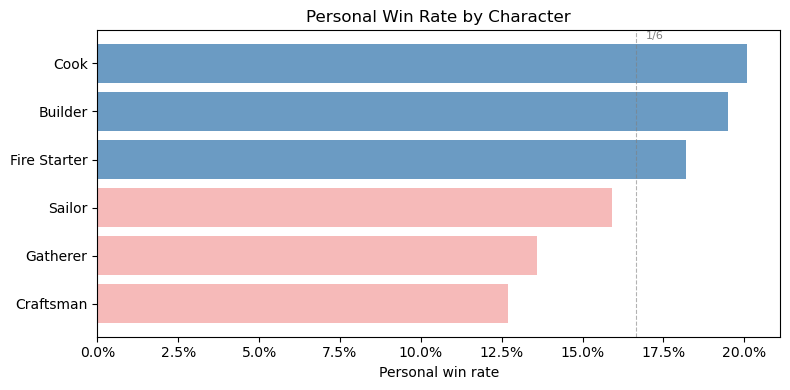

In [13]:
char_plot = char_summary.sort_values("personal_win_rate", ascending = True)
labels = char_plot["character"].str.replace("_", " ").str.title().values
personal_win_rates = char_plot["personal_win_rate"].values

bar_colors = ["steelblue" if rate >= 1 / 6 else "#f4a9a8" for rate in personal_win_rates]

plt.figure(figsize = (8, 4))

plt.barh(labels, personal_win_rates, color = bar_colors, alpha = 0.8, zorder = 2)
plt.axvline(1 / 6, linestyle = "--", color = "gray", linewidth = 0.8, alpha = 0.6)
plt.text(1 / 6 + 0.003, len(labels) - 0.5, "1/6", fontsize = 8, color = "gray")

plt.xlabel("Personal win rate")
plt.title("Personal Win Rate by Character")
plt.gca().xaxis.set_major_formatter(ticker.PercentFormatter(xmax = 1))

plt.tight_layout()
plt.show()

#### Character Group Win Power

For each character, this chart shows their average relative performance score in games the group wins versus games the group loses. Relative performance is computed as 7 − rank, where rank 1 means the highest scorer in that game. A relative performance score of 6 means the character was the top scorer; a score of 1 means they scored last.

Using rank rather than raw score removes the effect of game length: longer games produce higher absolute scores for everyone. By comparing relative standing within each game, the metric isolates each character's contribution independently of game duration.

The label above each group is the `group_win_power` delta: average relative performance in wins minus average relative performance in losses. A positive value means the character tends to perform better — relative to their teammates — when the group wins.

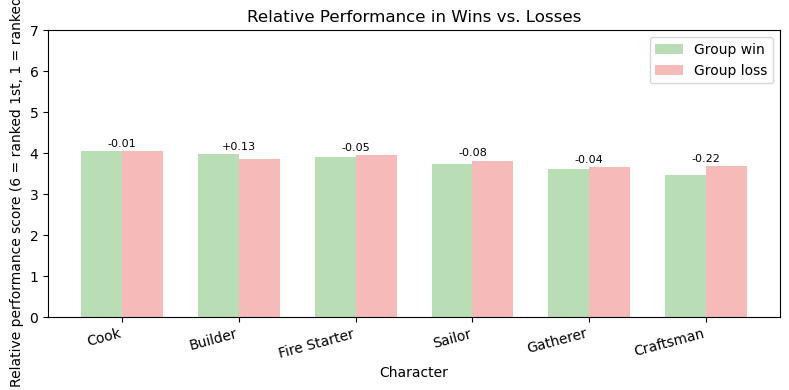

In [14]:
char_labels = char_summary["character"].str.replace("_", " ").str.title().values
x = np.arange(len(char_labels))
bar_width = 0.35

performance_on_win  = 7 - char_summary["avg_rank_on_group_win"].values
performance_on_loss = 7 - char_summary["avg_rank_on_group_loss"].values
group_win_power     = char_summary["group_win_power"].values

fig, ax = plt.subplots(figsize = (8, 4))

ax.bar(x - bar_width / 2, performance_on_win,  bar_width, label = "Group win",  color = "#a8d5a2", alpha = 0.8)
ax.bar(x + bar_width / 2, performance_on_loss, bar_width, label = "Group loss", color = "#f4a9a8", alpha = 0.8)

for i, power in enumerate(group_win_power):
    top = max(performance_on_win[i], performance_on_loss[i])
    ax.text(x[i], top + 0.1, f"{power:+.2f}", ha = "center", fontsize = 8)

ax.set_xticks(x)
ax.set_xticklabels(char_labels, rotation = 15, ha = "right")
ax.set_xlabel("Character")
ax.set_ylabel("Relative performance score (6 = ranked 1st, 1 = ranked last)")
ax.set_title("Relative Performance in Wins vs. Losses")
ax.set_ylim(0, 7)
ax.legend()

plt.tight_layout()
plt.show()

#### Average Score Differential

How far above or below the per-game average a character typically scores. A positive differential means the character earns more points than the average of their five teammates in a typical game; a negative differential means they earn fewer.

Because the differential is computed as each character's score minus the mean of all six scores in that game, the values are zero-sum: the six differentials always sum to zero. A large positive value indicates a structural scoring advantage built into the character's abilities or the missions they tend to drive.

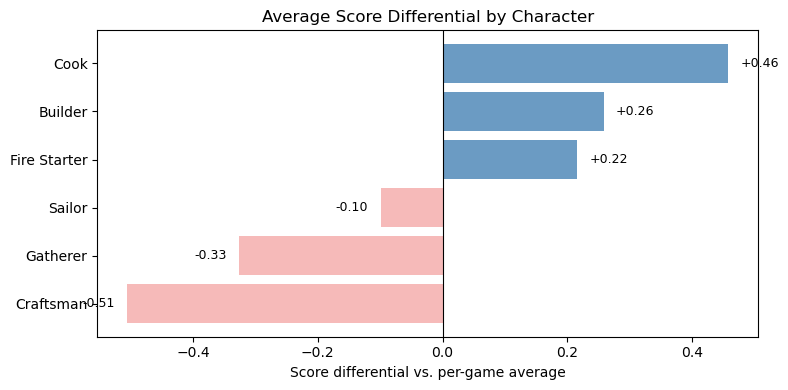

In [15]:
char_plot = char_summary.sort_values("avg_score_differential", ascending = True)
labels = char_plot["character"].str.replace("_", " ").str.title().values
differentials = char_plot["avg_score_differential"].values

bar_colors = ["steelblue" if differential >= 0 else "#f4a9a8" for differential in differentials]

plt.figure(figsize = (8, 4))

plt.barh(labels, differentials, color = bar_colors, alpha = 0.8, zorder = 2)
plt.axvline(0, color = "black", linewidth = 0.8)

for i, differential in enumerate(differentials):
    x_pos = differential + 0.02 if differential >= 0 else differential - 0.02
    horizontal_align = "left" if differential >= 0 else "right"
    plt.text(x_pos, i, f"{differential:+.2f}", va = "center", ha = horizontal_align, fontsize = 9)

plt.xlabel("Score differential vs. per-game average")
plt.title("Average Score Differential by Character")

plt.tight_layout()
plt.show()

#### Score Variability

Each point is one character, plotted by their average score (x-axis) and the standard deviation of their scores across all 1 000 games (y-axis).

High standard deviation means the character's output depends heavily on game state: how missions unfold, which complications appear, and whether their specific abilities were triggered frequently. Low standard deviation means the character scores consistently regardless of how the game goes.

The two dimensions together describe a character's scoring profile: a character in the upper-right scores high on average but inconsistently; one in the lower-left scores low and consistently; one in the upper-left scores inconsistently around a low mean; one in the lower-right scores consistently well (the ideal for balance).

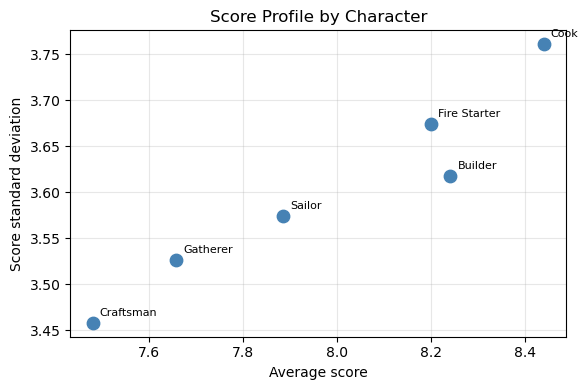

In [16]:
avg_scores = char_summary["avg_score"].values
score_stds = char_summary["score_std"].values
labels = char_summary["character"].str.replace("_", " ").str.title().values

plt.figure(figsize = (6, 4))

plt.scatter(avg_scores, score_stds, color = "steelblue", s = 80, zorder = 3)

for i, label in enumerate(labels):
    plt.annotate(
        label,
        xy         = (avg_scores[i], score_stds[i]),
        xytext     = (5, 5),
        textcoords = "offset points",
        fontsize   = 8,
    )

plt.xlabel("Average score")
plt.ylabel("Score standard deviation")
plt.title("Score Profile by Character")
plt.grid(True, alpha = 0.3, zorder = 0)

plt.tight_layout()
plt.show()